# UQ-SHRED Demo: Uncertainty Quantification for SHRED

This notebook demonstrates:
1. **Part 1:** Standard SHRED on SST data (baseline)
2. **Part 2:** UQ-SHRED with uncertainty quantification
3. **Part 3:** Temporal forecasting with UQ

We compare reconstruction quality (SHRED vs UQ-SHRED mean/median), show uncertainty bands, evaluate calibration, and compare forecast predictions. All results are saved to a timestamped results folder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
import os
from datetime import datetime

from processdata import load_data, TimeSeriesDataset
from models import SHRED, UQ_SHRED, UQ_Forecaster, fit, fit_uq, forecast_uq
import uq

# Settings
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset_name = 'SST'
print(f'Using device: {device}')

# Results directory with dataset and datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = f'results/{dataset_name}_{timestamp}'
os.makedirs(results_dir, exist_ok=True)
print(f'Results will be saved to: {results_dir}')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda
Results will be saved to: results/SST_20260213_220542


## Data Preparation (SST)

In [2]:
# Load data
num_sensors = 3
lags = 52  # 1 year of weekly data

load_X = load_data(dataset_name)
n, m = load_X.shape
print(f'{dataset_name} data shape: {load_X.shape} (timesteps, spatial dim)')

# Random sensor locations
sensor_locations = np.random.choice(m, size=num_sensors, replace=False)
print(f'Sensor locations: {sensor_locations}')

SST data shape: (1400, 44219) (timesteps, spatial dim)
Sensor locations: [28619  6515 13648]


In [3]:
# Train/valid/test split
train_indices = np.random.choice(n - lags, size=1000, replace=False)
mask = np.ones(n - lags)
mask[train_indices] = 0
valid_test_indices = np.arange(0, n - lags)[np.where(mask != 0)[0]]
valid_indices = valid_test_indices[::2]
test_indices = valid_test_indices[1::2]

print(f'Train: {len(train_indices)}, Valid: {len(valid_indices)}, Test: {len(test_indices)}')

Train: 1000, Valid: 174, Test: 174


In [4]:
# Train/valid/test split (80/10/10 sequential)
n_total = n - lags
train_size = int(0.8 * n_total)
valid_size = int(0.1 * n_total)

train_indices = np.arange(0, train_size)
valid_indices = np.arange(train_size, train_size + valid_size)
test_indices = np.arange(train_size + valid_size, n_total)

print(f'Train: {len(train_indices)}, Valid: {len(valid_indices)}, Test: {len(test_indices)}')

Train: 1078, Valid: 134, Test: 136


In [5]:
# Normalize
sc = MinMaxScaler()
sc = sc.fit(load_X[train_indices])
transformed_X = sc.transform(load_X)

# Generate input sequences
all_data_in = np.zeros((n - lags, lags, num_sensors))
for i in range(len(all_data_in)):
    all_data_in[i] = transformed_X[i:i+lags, sensor_locations]

# Create tensors
train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(device)
valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(device)
test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(device)

train_data_out = torch.tensor(transformed_X[train_indices + lags - 1], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(transformed_X[valid_indices + lags - 1], dtype=torch.float32).to(device)
test_data_out = torch.tensor(transformed_X[test_indices + lags - 1], dtype=torch.float32).to(device)

train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

print(f'Input shape: {train_data_in.shape}')
print(f'Output shape: {train_data_out.shape}')

Input shape: torch.Size([1078, 52, 3])
Output shape: torch.Size([1078, 44219])


---
# Part 1: Standard SHRED (Baseline)

In [6]:
# Train SHRED
shred = SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
shred_errors = fit(shred, train_dataset, valid_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Training epoch 1
Error tensor(0.4758, device='cuda:0')
Training epoch 20
Error tensor(0.2183, device='cuda:0')
Training epoch 40
Error tensor(0.2127, device='cuda:0')
Training epoch 60
Error tensor(0.2127, device='cuda:0')
Training epoch 80
Error tensor(0.2092, device='cuda:0')
Training epoch 100
Error tensor(0.2100, device='cuda:0')
Training epoch 120
Error tensor(0.2076, device='cuda:0')
Training epoch 140
Error tensor(0.2102, device='cuda:0')
Training epoch 160
Error tensor(0.2120, device='cuda:0')
Training epoch 180
Error tensor(0.2170, device='cuda:0')
Training epoch 200
Error tensor(0.2178, device='cuda:0')


In [7]:
# SHRED test error
shred.eval()
with torch.no_grad():
    shred_recon = shred(test_dataset.X)
    shred_error = (torch.linalg.norm(shred_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
print(f'SHRED Test Relative Error: {shred_error:.4f}')

SHRED Test Relative Error: 0.2263


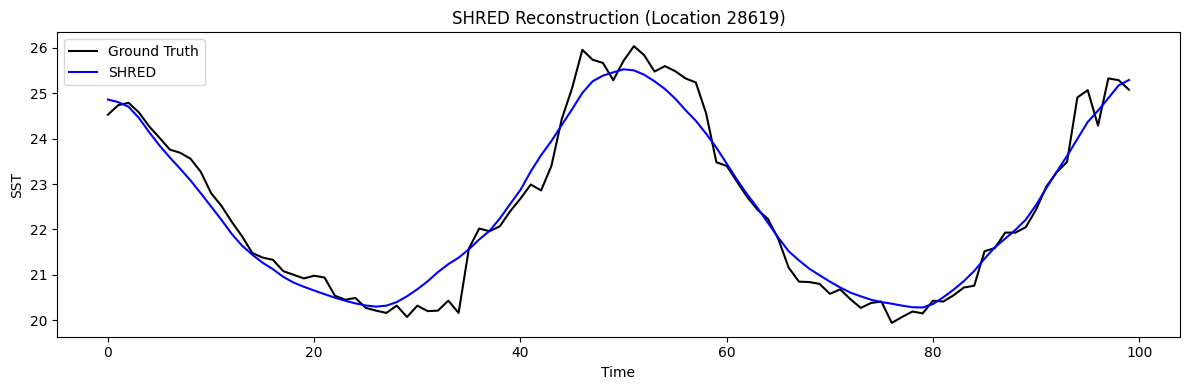

In [8]:
# Plot SHRED reconstruction (single sensor)
shred_recon_np = sc.inverse_transform(shred_recon.cpu().numpy())
test_truth_np = sc.inverse_transform(test_dataset.Y.cpu().numpy())

plt.figure(figsize=(12, 4))
idx = sensor_locations[0]
plt.plot(test_truth_np[:100, idx], 'k-', label='Ground Truth')
plt.plot(shred_recon_np[:100, idx], 'b-', label='SHRED')
plt.xlabel('Time')
plt.ylabel('SST')
plt.title(f'SHRED Reconstruction (Location {idx})')
plt.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/shred_reconstruction.png', dpi=150)
plt.show()

---
# Part 2: UQ-SHRED

In [9]:
# Train UQ-SHRED
uq_shred = UQ_SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1, noise_dim=50).to(device)
uq_errors = fit_uq(uq_shred, train_dataset, valid_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Epoch 1: error=0.5118
Epoch 20: error=0.2278
Epoch 40: error=0.2214
Epoch 60: error=0.2212
Epoch 80: error=0.2154
Epoch 100: error=0.2124
Epoch 120: error=0.2168
Epoch 140: error=0.2133
Epoch 160: error=0.2163
Epoch 180: error=0.2169
Epoch 200: error=0.2153


In [10]:
# UQ-SHRED test error (mean prediction)
uq_shred.eval()
mean_recon, std_recon = uq_shred.reconstruct(test_dataset.X, n_samples=100)
uq_error = (torch.linalg.norm(mean_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
print(f'UQ-SHRED Test Relative Error (mean): {uq_error:.4f}')
print(f'Average uncertainty (std): {std_recon.mean():.4f}')

UQ-SHRED Test Relative Error (mean): 0.2270
Average uncertainty (std): 0.0633


## Figure 1: Reconstruction with Uncertainty Bands

In [11]:
# Get samples for UQ analysis
samples = uq_shred.sample(test_dataset.X, n_samples=200)

# Inverse transform
samples_np = samples.cpu().numpy()
samples_orig = np.array([sc.inverse_transform(s) for s in samples_np])

mean_orig = samples_orig.mean(axis=0)
median_orig = np.median(samples_orig, axis=0)
lower_orig = np.percentile(samples_orig, 2.5, axis=0)
upper_orig = np.percentile(samples_orig, 97.5, axis=0)

# Median reconstruction error (in normalized space)
median_recon_normalized = np.median(samples_np, axis=0)
median_recon_tensor = torch.tensor(median_recon_normalized, dtype=torch.float32).to(device)
uq_median_error = (torch.linalg.norm(median_recon_tensor - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
print(f'UQ-SHRED Mean Reconstruction Error: {uq_error:.4f}')
print(f'UQ-SHRED Median Reconstruction Error: {uq_median_error:.4f}')

UQ-SHRED Mean Reconstruction Error: 0.2270
UQ-SHRED Median Reconstruction Error: 0.2288


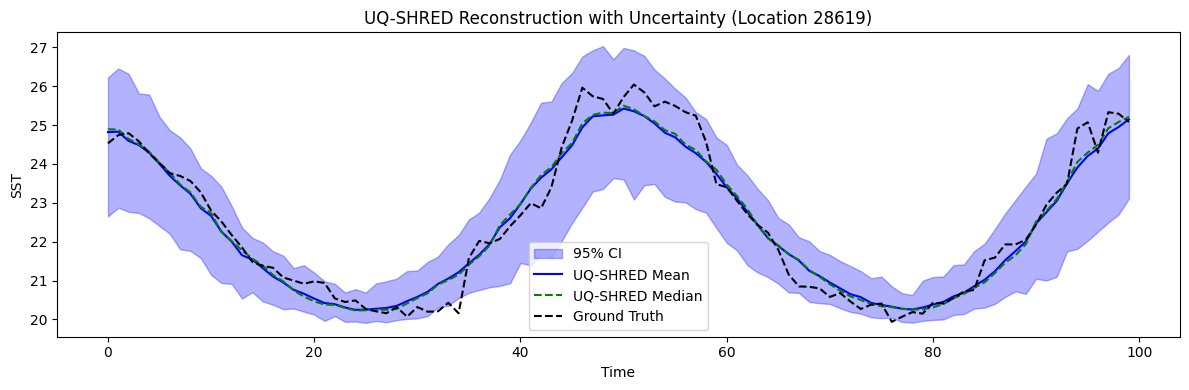

In [12]:
# Plot reconstruction with uncertainty bands (mean + median)
fig, ax = plt.subplots(figsize=(12, 4))
idx = sensor_locations[0]
t = np.arange(100)

ax.fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.3, color='blue', label='95% CI')
ax.plot(t, mean_orig[:100, idx], 'b-', linewidth=1.5, label='UQ-SHRED Mean')
ax.plot(t, median_orig[:100, idx], 'g--', linewidth=1.5, label='UQ-SHRED Median')
ax.plot(t, test_truth_np[:100, idx], 'k--', linewidth=1.5, label='Ground Truth')

ax.set_xlabel('Time')
ax.set_ylabel('SST')
ax.set_title(f'UQ-SHRED Reconstruction with Uncertainty (Location {idx})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/uq_shred_reconstruction.png', dpi=150)
plt.show()

## Figure 2: Multi-Sensor Uncertainty Grid

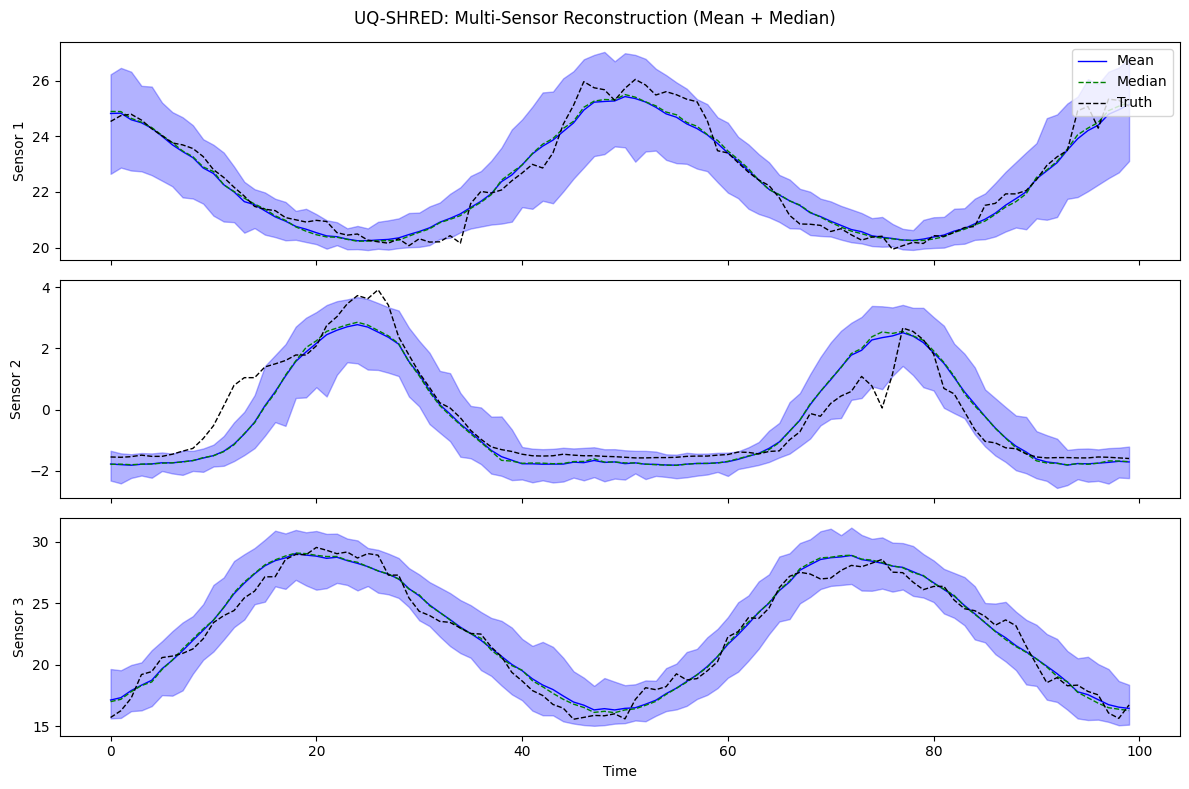

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t = np.arange(100)

for i, ax in enumerate(axes):
    idx = sensor_locations[i]
    ax.fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.3, color='blue')
    ax.plot(t, mean_orig[:100, idx], 'b-', linewidth=1, label='Mean')
    ax.plot(t, median_orig[:100, idx], 'g--', linewidth=1, label='Median')
    ax.plot(t, test_truth_np[:100, idx], 'k--', linewidth=1, label='Truth')
    ax.set_ylabel(f'Sensor {i+1}')
    if i == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
fig.suptitle('UQ-SHRED: Multi-Sensor Reconstruction (Mean + Median)')
plt.tight_layout()
plt.savefig(f'{results_dir}/uq_shred_multisensor.png', dpi=150)
plt.show()

## Figure 3: SHRED vs UQ-SHRED Reconstruction Comparison

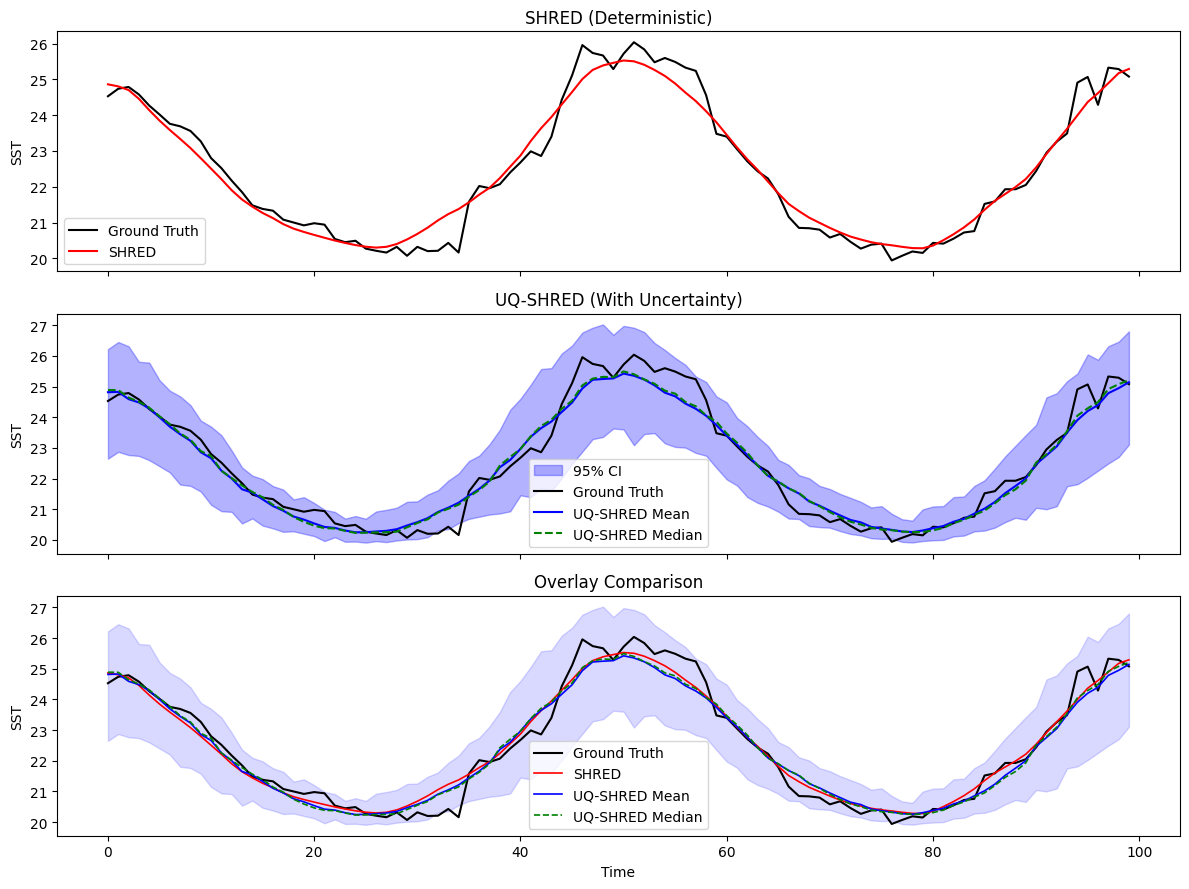

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
idx = sensor_locations[0]
t = np.arange(100)

# SHRED (deterministic)
axes[0].plot(t, test_truth_np[:100, idx], 'k-', label='Ground Truth')
axes[0].plot(t, shred_recon_np[:100, idx], 'r-', label='SHRED')
axes[0].set_ylabel('SST')
axes[0].legend()
axes[0].set_title('SHRED (Deterministic)')

# UQ-SHRED (with uncertainty, mean + median)
axes[1].fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, test_truth_np[:100, idx], 'k-', label='Ground Truth')
axes[1].plot(t, mean_orig[:100, idx], 'b-', label='UQ-SHRED Mean')
axes[1].plot(t, median_orig[:100, idx], 'g--', label='UQ-SHRED Median')
axes[1].set_ylabel('SST')
axes[1].legend()
axes[1].set_title('UQ-SHRED (With Uncertainty)')

# Overlay comparison
axes[2].plot(t, test_truth_np[:100, idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_recon_np[:100, idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_orig[:100, idx], 'b-', linewidth=1.2, label='UQ-SHRED Mean')
axes[2].plot(t, median_orig[:100, idx], 'g--', linewidth=1.2, label='UQ-SHRED Median')
axes[2].fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('SST')
axes[2].legend()
axes[2].set_title('Overlay Comparison')

plt.tight_layout()
plt.savefig(f'{results_dir}/shred_vs_uqshred.png', dpi=150)
plt.show()

## Metrics: Calibration

In [15]:
# Calibration scores
cal_scores = uq.calibration_scores(samples, test_dataset.Y, levels=[0.5, 0.7, 0.9, 0.95, 0.99])
print('Calibration (expected → observed):')
for level, obs in cal_scores.items():
    print(f'  {level*100:.0f}% CI → {obs*100:.1f}% coverage')

Calibration (expected → observed):
  50% CI → 33.8% coverage
  70% CI → 48.6% coverage
  90% CI → 67.9% coverage
  95% CI → 74.9% coverage
  99% CI → 83.3% coverage


## Figure 4: Calibration Diagram

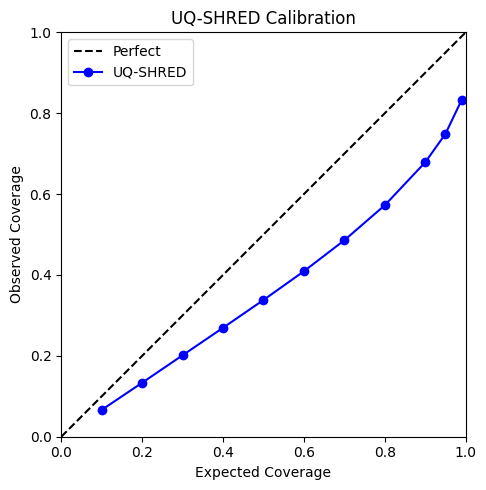

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
uq.plot_calibration(samples, test_dataset.Y, ax=ax)
ax.set_title('UQ-SHRED Calibration')
plt.tight_layout()
plt.savefig(f'{results_dir}/calibration_diagram.png', dpi=150)
plt.show()

## Metrics: CRPS and Sharpness

In [17]:
crps_score = uq.crps(samples, test_dataset.Y)
sharp = uq.sharpness(samples, conf=0.95)

print(f'CRPS: {crps_score:.4f} (lower is better)')
print(f'Sharpness (95% CI width): {sharp:.4f} (lower is sharper)')

CRPS: 0.0622 (lower is better)
Sharpness (95% CI width): 0.2443 (lower is sharper)


## Figure 5: Uncertainty vs Error

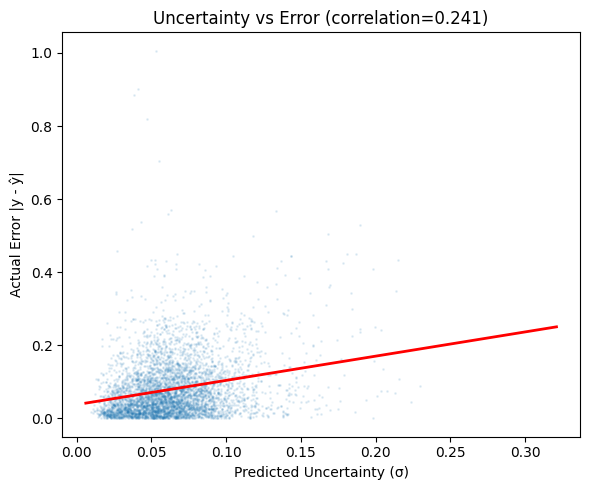

In [18]:
# Does uncertainty predict error?
errors = torch.abs(test_dataset.Y - mean_recon).flatten().cpu().numpy()
stds = std_recon.flatten().cpu().numpy()

# Subsample for plotting
idx = np.random.choice(len(errors), min(5000, len(errors)), replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(stds[idx], errors[idx], alpha=0.1, s=1)

# Trend line
z = np.polyfit(stds[idx], errors[idx], 1)
p = np.poly1d(z)
x_line = np.linspace(stds.min(), stds.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2)

corr = np.corrcoef(stds[idx], errors[idx])[0, 1]
ax.set_xlabel('Predicted Uncertainty (σ)')
ax.set_ylabel('Actual Error |y - ŷ|')
ax.set_title(f'Uncertainty vs Error (correlation={corr:.3f})')

plt.tight_layout()
plt.savefig(f'{results_dir}/uncertainty_vs_error.png', dpi=150)
plt.show()

---
# Part 3: Temporal Forecasting — SHRED vs UQ-SHRED Comparison

In [19]:
# Prepare forecaster training data
# Input: sensors[t-lags:t], Output: sensors[t]
sensor_data = transformed_X[:, sensor_locations]  # (n, num_sensors)

forecast_in = np.zeros((n - lags, lags, num_sensors))
forecast_out = np.zeros((n - lags, num_sensors))
for i in range(n - lags):
    forecast_in[i] = sensor_data[i:i+lags]
    forecast_out[i] = sensor_data[i+lags]

train_fc_in = torch.tensor(forecast_in[train_indices], dtype=torch.float32).to(device)
train_fc_out = torch.tensor(forecast_out[train_indices], dtype=torch.float32).to(device)
valid_fc_in = torch.tensor(forecast_in[valid_indices], dtype=torch.float32).to(device)
valid_fc_out = torch.tensor(forecast_out[valid_indices], dtype=torch.float32).to(device)

train_fc_dataset = TimeSeriesDataset(train_fc_in, train_fc_out)
valid_fc_dataset = TimeSeriesDataset(valid_fc_in, valid_fc_out)

# Train deterministic SHRED forecaster (for comparison)
print('Training deterministic SHRED forecaster...')
shred_forecaster = SHRED(num_sensors, num_sensors, hidden_size=64, hidden_layers=2, l1=100, l2=150, dropout=0.1).to(device)
fc_shred_errors = fit(shred_forecaster, train_fc_dataset, valid_fc_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Training deterministic SHRED forecaster...
Training epoch 1
Error tensor(0.5795, device='cuda:0')
Training epoch 20
Error tensor(0.1195, device='cuda:0')
Training epoch 40
Error tensor(0.1198, device='cuda:0')
Training epoch 60
Error tensor(0.1020, device='cuda:0')
Training epoch 80
Error tensor(0.1031, device='cuda:0')
Training epoch 100
Error tensor(0.0850, device='cuda:0')
Training epoch 120
Error tensor(0.0884, device='cuda:0')
Training epoch 140
Error tensor(0.0935, device='cuda:0')
Training epoch 160
Error tensor(0.0799, device='cuda:0')
Training epoch 180
Error tensor(0.0767, device='cuda:0')
Training epoch 200
Error tensor(0.0808, device='cuda:0')


In [20]:
# Train UQ-Forecaster
forecaster = UQ_Forecaster(input_size=num_sensors, hidden_size=64, hidden_layers=2, noise_dim=50).to(device)
fc_errors = fit_uq(forecaster, train_fc_dataset, valid_fc_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Epoch 1: error=0.5906
Epoch 20: error=0.1248
Epoch 40: error=0.1092
Epoch 60: error=0.1072
Epoch 80: error=0.1070
Epoch 100: error=0.0943
Epoch 120: error=0.0912
Epoch 140: error=0.0838
Epoch 160: error=0.0843
Epoch 180: error=0.0780
Epoch 200: error=0.0782


In [21]:
# Generate forecast trajectories
horizon = 50
initial = test_data_in[0:1]  # Start from first test point

# --- Deterministic SHRED forecast (autoregressive) ---
shred_forecaster.eval()
with torch.no_grad():
    history = initial.clone()
    shred_traj = []
    for t in range(horizon):
        next_val = shred_forecaster(history)
        shred_traj.append(next_val.cpu().numpy().squeeze())
        history = torch.cat([history[:, 1:, :], next_val.unsqueeze(1)], dim=1)
shred_traj = np.array(shred_traj)  # (horizon, num_sensors)

# --- UQ forecast samples ---
uq_traj_samples = forecaster.sample_trajectory(initial, horizon=horizon, n_samples=100)
uq_traj_samples = uq_traj_samples.squeeze(1).cpu().numpy()  # (n_samples, horizon, num_sensors)

mean_traj = uq_traj_samples.mean(axis=0)  # (horizon, num_sensors)
median_traj = np.median(uq_traj_samples, axis=0)
std_traj = uq_traj_samples.std(axis=0)

# Ground truth future sensors
start_idx = test_indices[0] + lags
gt_future = sensor_data[start_idx:start_idx+horizon]

# Forecast errors
shred_fc_error = np.linalg.norm(shred_traj - gt_future) / np.linalg.norm(gt_future)
uq_mean_fc_error = np.linalg.norm(mean_traj - gt_future) / np.linalg.norm(gt_future)
uq_median_fc_error = np.linalg.norm(median_traj - gt_future) / np.linalg.norm(gt_future)

print(f'SHRED forecast relative error:     {shred_fc_error:.4f}')
print(f'UQ forecast mean relative error:    {uq_mean_fc_error:.4f}')
print(f'UQ forecast median relative error:  {uq_median_fc_error:.4f}')

SHRED forecast relative error:     0.2066
UQ forecast mean relative error:    0.1395
UQ forecast median relative error:  0.1435


## Figure 6: SHRED vs UQ-SHRED Forecast Comparison

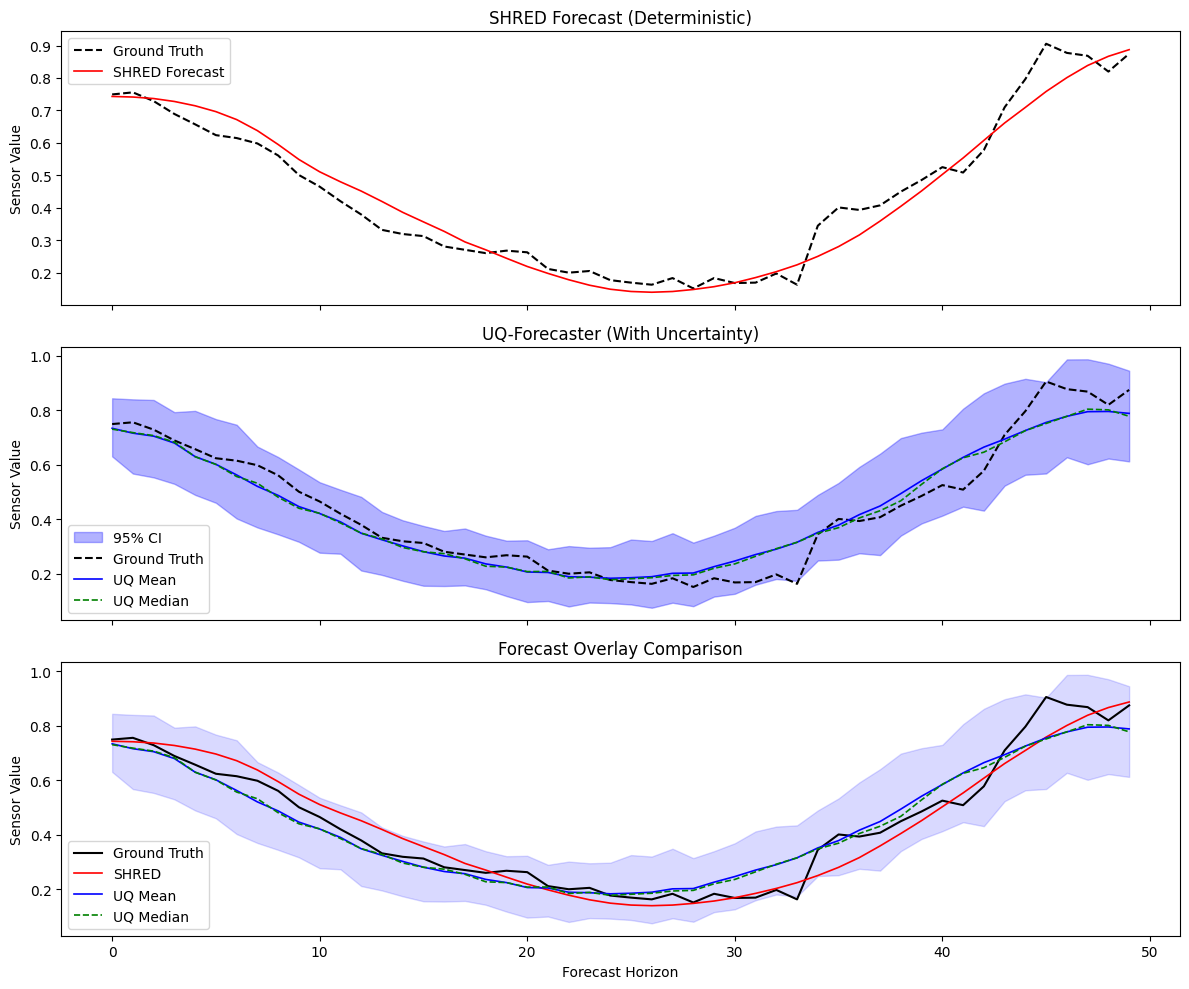

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
t = np.arange(horizon)
sensor_idx = 0

lower_traj = np.percentile(uq_traj_samples, 2.5, axis=0)
upper_traj = np.percentile(uq_traj_samples, 97.5, axis=0)

# SHRED deterministic forecast
axes[0].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[0].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED Forecast')
axes[0].set_ylabel('Sensor Value')
axes[0].legend()
axes[0].set_title('SHRED Forecast (Deterministic)')

# UQ-SHRED forecast with mean and median
axes[1].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx],
                alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[1].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[1].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[1].set_ylabel('Sensor Value')
axes[1].legend()
axes[1].set_title('UQ-Forecaster (With Uncertainty)')

# Overlay comparison
axes[2].plot(t, gt_future[:, sensor_idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[2].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[2].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Forecast Horizon')
axes[2].set_ylabel('Sensor Value')
axes[2].legend()
axes[2].set_title('Forecast Overlay Comparison')

plt.tight_layout()
plt.savefig(f'{results_dir}/forecast_comparison.png', dpi=150)
plt.show()

## Figure 7: Uncertainty and Error Growth Over Horizon

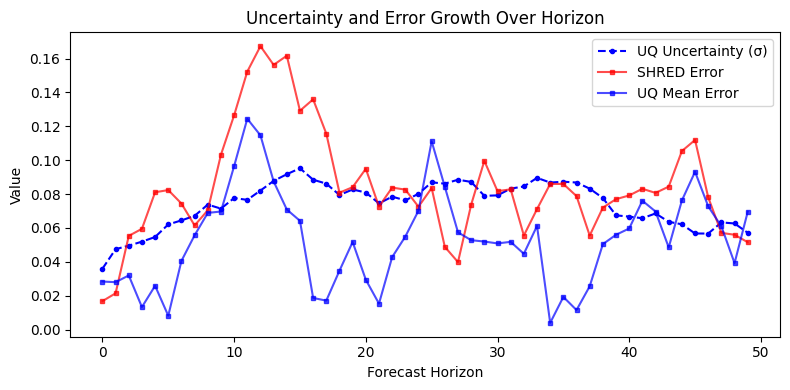

In [23]:
# Uncertainty and error growth over horizon
avg_std = std_traj.mean(axis=1)
shred_error_horizon = np.abs(shred_traj - gt_future).mean(axis=1)
uq_error_horizon = np.abs(mean_traj - gt_future).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(horizon), avg_std, 'b--', marker='o', markersize=3, label='UQ Uncertainty (σ)')
ax.plot(np.arange(horizon), shred_error_horizon, 'r-', marker='s', markersize=3, alpha=0.7, label='SHRED Error')
ax.plot(np.arange(horizon), uq_error_horizon, 'b-', marker='s', markersize=3, alpha=0.7, label='UQ Mean Error')
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Value')
ax.set_title('Uncertainty and Error Growth Over Horizon')
ax.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/uncertainty_growth.png', dpi=150)
plt.show()

---
# Summary Table

In [24]:
summary_lines = []
summary_lines.append('=' * 75)
summary_lines.append('RESULTS SUMMARY')
summary_lines.append('=' * 75)
summary_lines.append(f'Dataset: {dataset_name}')
summary_lines.append(f'Timestamp: {timestamp}')
summary_lines.append(f'Sensors: {num_sensors}, Lags: {lags}')
summary_lines.append('')
summary_lines.append(f'{"Metric":<30} {"SHRED":<15} {"UQ Mean":<15} {"UQ Median":<15}')
summary_lines.append('-' * 75)
summary_lines.append(f'{"Recon Relative Error":<30} {shred_error:<15.4f} {uq_error:<15.4f} {uq_median_error:<15.4f}')
summary_lines.append(f'{"Forecast Relative Error":<30} {shred_fc_error:<15.4f} {uq_mean_fc_error:<15.4f} {uq_median_fc_error:<15.4f}')
summary_lines.append(f'{"CRPS":<30} {"---":<15} {crps_score:<15.4f} {"---":<15}')
summary_lines.append(f'{"Sharpness (95% CI)":<30} {"---":<15} {sharp:<15.4f} {"---":<15}')
summary_lines.append(f'{"Coverage (95% CI)":<30} {"---":<15} {cal_scores[0.95]*100:<14.1f}% {"---":<15}')
summary_lines.append(f'{"UQ-Error Correlation":<30} {"---":<15} {corr:<15.3f} {"---":<15}')
summary_lines.append('=' * 75)

summary_text = '\n'.join(summary_lines)
print(summary_text)

# Save metrics to file
with open(f'{results_dir}/metrics.txt', 'w') as f:
    f.write(summary_text + '\n')
print(f'\nMetrics saved to {results_dir}/metrics.txt')

RESULTS SUMMARY
Dataset: SST
Timestamp: 20260213_220542
Sensors: 3, Lags: 52

Metric                         SHRED           UQ Mean         UQ Median      
---------------------------------------------------------------------------
Recon Relative Error           0.2263          0.2270          0.2288         
Forecast Relative Error        0.2066          0.1395          0.1435         
CRPS                           ---             0.0622          ---            
Sharpness (95% CI)             ---             0.2443          ---            
Coverage (95% CI)              ---             74.9          % ---            
UQ-Error Correlation           ---             0.241           ---            

Metrics saved to results/SST_20260213_220542/metrics.txt


In [25]:
print(f'All results saved to: {results_dir}/\n')
print('Saved outputs:')
for fname in ['shred_reconstruction.png', 'uq_shred_reconstruction.png',
              'uq_shred_multisensor.png', 'shred_vs_uqshred.png',
              'calibration_diagram.png', 'uncertainty_vs_error.png',
              'forecast_comparison.png', 'uncertainty_growth.png',
              'metrics.txt']:
    print(f'  - {fname}')

All results saved to: results/SST_20260213_220542/

Saved outputs:
  - shred_reconstruction.png
  - uq_shred_reconstruction.png
  - uq_shred_multisensor.png
  - shred_vs_uqshred.png
  - calibration_diagram.png
  - uncertainty_vs_error.png
  - forecast_comparison.png
  - uncertainty_growth.png
  - metrics.txt
